In [1]:
import pickle
from pathlib import Path
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import pandas as pd

from keras.src.callbacks import EarlyStopping
from keras.src.layers import Dropout, Dense, BatchNormalization, Input, Flatten, LSTM
import torch.nn as nn
import tensorflow as tf
import keras
from  keras.src import Model

from keras.src.layers import Input, Dense,  Flatten
from keras.src.layers import BatchNormalization, Activation, Conv2DTranspose
from keras.src.models import Model, Sequential
from keras.src.layers import LeakyReLU, Reshape, Conv2D, UpSampling2D, ReLU
from keras.src import initializers

In [2]:
def preprocess(X: pd.DataFrame, cloud_dataset=False):
    """
    The function will preprocess the data:
    1. Categorical features will be label encoded (Boy->1, Girl ->2)
    2. Numerical features will be scaled if the data is intended to be used for baseline. For cloud data set, no scaling will be preformed.

    Return pd.Dataframe
    """
    # Identify categorical and numeric columns
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

    # Initialize lists to store processed columns
    processed_columns = []

    # If there are categorical columns, apply one-hot encoding
    if categorical_cols:
        print("\nEncoding categorical columns...")
        X_categorical = pd.get_dummies(X[categorical_cols], drop_first=True)
        # label_encoder = LabelEncoder()
        # X_categorical = pd.DataFrame()
        # for col in categorical_cols:
        #     # X_categorical[col] = label_encoder.fit_transform(X[col])
        processed_columns.append(X_categorical)

    # Apply standard scaling to the numeric columns
    if numeric_cols:
        print("\nScaling numerical columns...")
        scaler = MinMaxScaler()
        # X_numeric = X[numeric_cols]
        # if cloud_dataset:
        X_numeric = pd.DataFrame(scaler.fit_transform(X[numeric_cols]), columns=numeric_cols, index=X.index)
        # else:
        #     X_numeric = pd.DataFrame(scaler.fit_transform(X[numeric_cols]), columns=numeric_cols, index=X.index)

        processed_columns.append(X_numeric)

    # Combine the processed columns
    if processed_columns:
        X_processed = pd.concat(processed_columns, axis=1)
    else:
        X_processed = X.copy()  # If there are no categorical or numeric columns, keep the original dataframe


    return X_processed

In [3]:
class RawDataset:
    name: str

    def __init__(self, **kwargs):

        self.X, self.y = None, None
        self.sample_split = 1
        self.baseline_model = "neural_network"
        self.name = None
        self.metadata = {}

    def get_n_classes(self):
        return len(np.unique(self.y))

    def get_number_of_features(self):
        return self.X.shape[1]

    def get_dataset(self):
        return self.X, self.y


    def _get_model(self, X_train, y_train):
        inputs = Input(shape=(X_train.shape[1],))  # Dynamic input shape

        # Define the hidden layers
        x = BatchNormalization()(inputs)
        x = Dense(units=128, activation='leaky_relu')(x)
        x = Dropout(0.3)(x)

        # x = Dense(units=64, activation='leaky_relu')(x)
        # x = Dropout(0.3)(x)

        # Define the output layer
        outputs = Dense(units=len(np.unique(y_train)), activation='softmax')(x)

        # Create the model
        clf = Model(inputs=inputs, outputs=outputs)

        # Compile the model with F1 Score
        clf.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      )

        return clf

In [19]:
import pathlib
from pmlb import fetch_data

PROJECT_DIR = "/Users/eden.yavin/Projects/Tabular-Cloud-ML"

DATASETS_DIR = "data"
DATASETS_PATH = os.path.join(PROJECT_DIR, DATASETS_DIR)
DATASET_NAME_TOKEN = "dataset_name"
DATASET_FILE_NAME = "dataset.pkl"
DATASET_DIR = pathlib.Path(DATASETS_PATH)
DATASET_NAME = "mushroom"

class PMLBDataset(RawDataset):

    def __init__(self,  **kwargs):
        super().__init__(**kwargs)
        dataset_name = kwargs.get(DATASET_NAME_TOKEN)
        DATASET_PATH = DATASET_DIR / dataset_name
        file_path = DATASET_PATH / "dataset.csv"
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            if "Unnamed: 0" in dataset.columns:
                dataset.drop(columns=["Unnamed: 0"], inplace=True)
        else:
            dataset = fetch_data(dataset_name)
            os.makedirs(DATASET_PATH, exist_ok=True)
            dataset.to_csv(file_path, index=False)

        self.X, self.y = self._preprocess(dataset)
        self.cloud_models = kwargs.get("cloud_models")
        self.name = dataset_name
        self.metadata["labels"] = [0, 1]
        self.metadata['targe_column'] = "target"

    def _preprocess(self, dataset: pd.DataFrame):
        dataset = dataset.dropna().sample(frac=1, random_state=42).reset_index(drop=True)
        X,y = dataset.drop(columns=["target"]), dataset["target"]
        return preprocess(X, cloud_dataset=True), y

dataset = PMLBDataset(dataset_name="mushroom")


Scaling numerical columns...


In [5]:
class SparseAE(nn.Module):
    name: str = "sparse_ae"

    def __init__(self, **kwargs):
        super(SparseAE, self).__init__()
        X = kwargs.get("X")
        self.model = self._get_trained_model(X.astype(float))
        self.output_shape = (1, 64)

    def forward(self, x):

        if type(x) is pd.DataFrame:
            x = x.to_numpy()

        embedding = self.model(x)
        return embedding

    def _get_trained_model(self, X:np.ndarray | pd.DataFrame):

        def sparse_loss(y_true, y_pred):
            sparsity_level = 0.05
            lambda_sparse = 0.1
            mse_loss = tf.reduce_mean(keras.losses.MeanSquaredError()(y_true, y_pred))
            hidden_layer_output = encoder(y_true)
            mean_activation = tf.reduce_mean(hidden_layer_output, axis=0)

            kl_divergence = tf.reduce_sum(sparsity_level * tf.math.log(sparsity_level / (mean_activation + 1e-10)) +
                                          (1 - sparsity_level) * tf.math.log(
                (1 - sparsity_level) / (1 - mean_activation + 1e-10)))

            return mse_loss + lambda_sparse * kl_divergence

        input_dim = X.shape[1]
        encoding_dim = max(int(input_dim * 1.5), 64)
        inputs = Input(shape=(input_dim,))
        encoded = Dense(encoding_dim, activation="relu")(inputs)
        decoded = Dense(input_dim, activation='sigmoid')(encoded)

        autoencoder = keras.Model(inputs, decoded)
        encoder = keras.Model(inputs, encoded)
        early_stop = EarlyStopping(patience=2, monitor="loss")

        autoencoder.compile(optimizer='adam', loss=sparse_loss)
        autoencoder.fit(X, X, epochs=50, batch_size=256, shuffle=True, callbacks=[early_stop])

        return encoder

model = SparseAE(X=dataset.X)

Epoch 1/50


2025-07-16 11:05:25.989063: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-07-16 11:05:25.989096: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2025-07-16 11:05:25.989100: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2025-07-16 11:05:25.989116: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-16 11:05:25.989124: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-07-16 11:05:26.306344: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9014
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9396
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7053
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6345
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6035
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5888
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5786
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5715
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5642
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5579
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5539
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5493
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5460
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5423
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5390
Epoch 16/50
32/32 ━━━━━━━━━━━━

In [6]:
import json

from sklearn.model_selection import train_test_split

class RawDataExperimentDatabase:
    """
    This will enable consistent experiments - Each split of dataset will be save, i.e. the indexes will be saved.
    Thus changes to the data will not result in changes to the split
    """
    def __init__(self, dataset: RawDataset):
        self.dataset = dataset
        db_path = os.path.join("..","data", dataset.name)
        os.makedirs(db_path, exist_ok=True)
        self.db_path = os.path.join(db_path, f"{dataset.name}_dataset.json")
        self.key = str(1)
        if os.path.exists(self.db_path):
            print(f"Path exists: {self.db_path}")
            self.db = json.load(open(self.db_path, "r"))
            self.empty = False if self.key in self.db else True
        else:
            self.db = {1: {}}
            self.empty = True


    def _save(self):
        with open(self.db_path, "w") as f:
            json.dump(self.db, f)

    def get_split(self):

        X, y = self.dataset.get_dataset()

        if self.empty:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y,
                                                                random_state=42)


            X_sample, y_sample = X_train, y_train


            new_data = {}
            new_data["train_index"] = X_train.index.tolist()
            new_data["imm_train_index"] = X_sample.index.tolist()
            new_data["test_index"] = X_test.index.tolist()

            self.db[self.key] = new_data

            print(f"#### CREATED NEW INDEX FOR 1 - INDEX SIZE {len(X_sample)}")

            self._save()

        else:
            indexes = self.db[self.key]
            # Get the existing indices and create new dataframes
            X_train = pd.DataFrame(X.loc[indexes["train_index"]])
            y_train = pd.Series(y.loc[indexes["train_index"]])
            X_sample = pd.DataFrame(X.loc[indexes["imm_train_index"]])
            y_sample = pd.Series(y.loc[indexes["imm_train_index"]])
            X_test = pd.DataFrame(X.loc[indexes["test_index"]])
            y_test = pd.Series(y.loc[indexes["test_index"]])
            print(f"LOADED INDEX 1 - INDEX SIZE {len(X_sample)}")

        return X_train.values, X_test.values, X_sample.values, y_train.values, y_test.values, y_sample.values


In [7]:
X_train, X_test, X_sample, y_train, y_test, y_sample = RawDataExperimentDatabase(dataset).get_split()

Path exists: ../data/mushroom/mushroom_dataset.json
LOADED INDEX 1 - INDEX SIZE 7311


In [8]:
X_train_emb = model.forward(X_sample).numpy()
X_test_emb = model.forward(X_test).numpy()

In [9]:
from tensorflow.keras.utils import to_categorical

# Convert integer labels to one-hot encoded labels
y_train_one_hot = to_categorical(y_train, num_classes=2)
y_test_one_hot = to_categorical(y_test, num_classes=2)

In [32]:
from keras.src.metrics import F1Score
from keras.src.callbacks import LearningRateScheduler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, f1_score

class NeuralNetworkInternalModel(BaseEstimator, ClassifierMixin):

    def __init__(self, **kwargs):
        self.batch_size = 64
        self.dropout_rate = 0.3
        self.epochs = kwargs.get("epochs", 100)

        self.model: Model = None

    def fit(self, X, y, validation_data=None):
        lr_scheduler = LearningRateScheduler(lambda epoch: 0.0001 * (0.9 ** epoch))
        early_stopping = EarlyStopping(patience=2, monitor='loss')
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, callbacks=[lr_scheduler, early_stopping], validation_data=validation_data, verbose=2)

    def predict(self, X):
        prediction = self.model.predict(X)
        return np.argmax(prediction, axis=1)

    def predict_proba(self, X):
        return self.model.predict(X)

    def evaluate(self, X, y):
        if len(y.shape) == 2:
            y = np.argmax(y, axis=1)

        pred = self.predict(X)
        return accuracy_score(y, pred), f1_score(y, pred, average='weighted')


class LSTMIIM(NeuralNetworkInternalModel):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.name = "lstm"
        num_classes = kwargs.get("num_classes")
        input_shape = kwargs.get("input_shape")
        self.model = self.get_model(num_classes=num_classes, input_shape=input_shape)

    def get_model(self, num_classes, input_shape):

        inputs = Input(shape=(1, input_shape))

        x = LSTM(units=256, return_sequences=True)(inputs)

        x = LSTM(units=128, return_sequences=True)(x)

        x = LSTM(units=64, return_sequences=False)(x)

        # Dense layers with dropout
        x = Dense(32, activation='leaky_relu')(x)
        x = Dense(16, activation='leaky_relu')(x)
        outputs = Dense(num_classes, activation='softmax')(x)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    @staticmethod
    def prepare_data_for_training(X,y):
        return tf.reshape(X, [-1, 1, X.shape[-1]]), y

    def fit(self, X, y, validation_data=None):
        X = X.reshape(-1, 1, X.shape[1])
        if validation_data:
            X_val, y_val = validation_data
            X_val = X_val.reshape(-1, 1, X_val.shape[1])
            validation_data = (X_val, y_val)

        super().fit(X, y, validation_data=validation_data)

    def evaluate(self, X, y):
        X = X.reshape(-1, 1, X.shape[1])
        return super().evaluate(X, y)


In [17]:
|import matplotlib.pyplot as plt # For visualization
import pickle
from openTSNE import TSNE

def visualize(triangulations, dataset_name, acc=None):
    # triangulations = data.train.features[1, : 512 * 6].reshape(6, 512)

    tsne_model = TSNE(
        n_components=2,       # For 2D visualization
        perplexity=1.33,
        random_state=42,      # For reproducibility
        metric="euclidean",   # Default metric
        n_jobs=-1             # Use all available CPU cores
    )
    embedding = tsne_model.fit(triangulations)
    plt.figure(figsize=(10, 8))

    if embedding is not None:
        plt.scatter(embedding[:, 0], embedding[:, 1], s=100) # s is marker size
        # You can add labels if these 5 "samples" have distinct meanings
        for i in range(embedding.shape[0]):
            plt.text(embedding[i, 0] + 0.02, embedding[i, 1] + 0.02, f"Sample {i+1}", fontsize=9)
    title = f't-SNE visualization of 5 derived samples, Dataset {dataset_name}'
    if acc is not None:
        title += f', Original Accuracy On Data: {acc:.4f}'
    plt.title(title)
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.grid(True)
    plt.show()

In [12]:
def get_triangulation_samples(how_to_choose,n_samples, embeddings):


    if how_to_choose == 'random':
        indices = np.random.choice(len(embeddings), size=n_samples,
                                   replace=False)
        triangulation_samples = embeddings[indices]

    elif how_to_choose == 'first':
        triangulation_samples = embeddings[:n_samples]

    else:
        triangulation_samples = embeddings[-n_samples:]

    return triangulation_samples

In [56]:
from keras.api.models import load_model


class BaseEncryptor:

    name: str

    def __init__(self, dataset_name: str,output_shape=None):
        self.model = None
        self.output_shape = output_shape
        self.input_shape = None
        self.dataset_name = dataset_name
        self.seed = 1

    def build_generator(self, input_shape, output_shape, seed=None):
        raise NotImplementedError("Subclasses should implement this method")

    def save_model(self, filename):
        if self.model is not None:
            self.model.save(filename)  # For Keras models

    def load_model(self, filename):
        self.model = load_model(filename)  # For Keras models

    def switch_key(self):
        self.reset_weights_in_place(seed=self.seed)
        self.seed += 1

    def reset_weights_in_place(self, seed):
        for layer in self.model.layers:
            if isinstance(layer, tf.keras.Model):
                self.reset_weights_in_place(seed)
                continue

            # You can expand this based on layer types or your model structure
            if hasattr(layer, 'kernel'):
                init = initializers.GlorotUniform(seed=seed)
                layer.kernel.assign(init(layer.kernel.shape, layer.kernel.dtype))

            if hasattr(layer, 'bias') and layer.bias is not None:
                init = initializers.Zeros()  # Bias is usually Zeros by default
                layer.bias.assign(init(layer.bias.shape, layer.bias.dtype))

            # if isinstance(layer, tf.keras.layers.BatchNormalization):
            #     # Reset batch norm non-trainable params if needed
            #     for attr in ['gamma', 'beta', 'moving_mean', 'moving_variance']:
            #         var = getattr(layer, attr, None)
            #         if var is not None:
            #             init = tf.keras.initializers.Ones() if 'gamma' in attr else tf.keras.initializers.Zeros()
            #             var.assign(init(var.shape, var.dtype))

    def encode(self, inputs) -> np.array:

        self.input_shape = inputs.shape[1:]
        self.output_shape = self.output_shape or (1, inputs.shape[2])

        if self.model is None:
            self.model = self.build_generator(self.input_shape, self.output_shape)
            self.seed += 1

        return self.model(inputs).numpy()

class DCEncryptor(BaseEncryptor):

    name = "dc"

    def build_generator(self, input_shape, output_shape, seed=None):

        # Ziv's Model
        G = Sequential()
        G.add(Reshape(target_shape=[1,1, *input_shape], input_shape=input_shape))

        # 1x1x4096
        G.add(Conv2DTranspose(filters=64, kernel_size=4))
        G.add(Activation('relu'))
        # Weights index: 0, Activations index: 1

        # 4x4x64
        G.add(Conv2D(filters=64, kernel_size=4, padding='same',kernel_initializer=initializers.GlorotUniform(seed=seed)))
        G.add(BatchNormalization(momentum=0.7))
        G.add(Activation('relu'))
        # Weights index: 2, Activations index: 5
        G.add(UpSampling2D())
        # No weights or activations here

        # 8x8x64
        G.add(Conv2D(filters=32, kernel_size=4, padding='same', kernel_initializer=initializers.GlorotUniform(seed=seed)))
        G.add(BatchNormalization(momentum=0.7))
        G.add(Activation('relu'))
        # Weights index: 8, Activations index: 9
        G.add(UpSampling2D())
        # No weights or activations here

        # 16x16x32
        G.add(Conv2D(filters=16, kernel_size=4, padding='same', kernel_initializer=initializers.GlorotUniform(seed=seed)))
        G.add(BatchNormalization(momentum=0.7))
        G.add(Activation('relu'))
        # Weights index: 14, Activations index: 13
        G.add(UpSampling2D())
        # No weights or activations here

        # 32x32x16
        G.add(Conv2D(filters=8, kernel_size=4, padding='same', kernel_initializer=initializers.GlorotUniform(seed=seed)))
        G.add(BatchNormalization(momentum=0.7))
        G.add(Activation('relu'))
        # Weights index: 20, Activations index: 17
        G.add(UpSampling2D())
        # No weights or activations here

        # 64x64x8
        G.add(Conv2D(filters=4, kernel_size=4, padding='same', kernel_initializer=initializers.GlorotUniform(seed=seed)))
        G.add(BatchNormalization(momentum=0.7))
        G.add(Activation('relu'))
        # Weights index: 26, Activations index: 21
        G.add(UpSampling2D())
        # No weights or activations here

        # 128x128x4
        G.add(Conv2D(filters=3, kernel_size=4, padding='same', kernel_initializer=initializers.GlorotUniform(seed=seed)))
        # G.add(Activation('sigmoid'))
        G.add(Activation('relu'))
        # Weights index: 32, Activations index: 25

        return G

encryptor = DCEncryptor(dataset_name="mushroom",output_shape=(299, 299, 3))


In [57]:
from transformers import CLIPModel, CLIPProcessor
import torch

STORE_DIR = "store"
STORE_PATH = os.path.join(PROJECT_DIR, STORE_DIR)
os.makedirs(STORE_PATH, exist_ok=True)
MODELS_DIR = "models"
MODELS_PATH = os.path.join(STORE_PATH, MODELS_DIR)
os.makedirs(MODELS_PATH, exist_ok=True)

class ClipEmbedding(nn.Module):

    name = "clip_embedding"

    def __init__(self, **kwargs):
        super(ClipEmbedding, self).__init__()
        model_id = "openai/clip-vit-base-patch32"
        self.input_shape = (224, 224)
        try:
            self.model = CLIPModel.from_pretrained(model_id, cache_dir=MODELS_PATH)
            self.processor = CLIPProcessor.from_pretrained(model_id, cache_dir=MODELS_PATH)
        except:
            self.model = CLIPModel.from_pretrained(model_id, cache_dir=MODELS_PATH, local_files_only=True)
            self.processor = CLIPProcessor.from_pretrained(model_id, cache_dir=MODELS_PATH, local_files_only=True)
        self.output_shape = (1, 512)

    def forward(self, x):

        image_input = self.processor(images=x, return_tensors="pt", do_rescale=False)["pixel_values"]
        with torch.no_grad():
            embeddings = self.model.get_image_features(pixel_values=image_input)
        # embedding is your flat vector (e.g., 512-dim)[6]
        return embeddings.numpy()

triangulation_embedding = ClipEmbedding()

In [61]:
from tqdm.notebook import tqdm

def get_dataset(X, triangulation_samples ):
    with tqdm(total=len(X), leave=True, position=0, desc="Encrypting, Embedding, Predicting") as pbar:

        observations =  []
        for x in X:
            pbar.update(1)
            # Triangulation features vector = X', Y_1', Y_2',...
            x_tag = encryptor.encode(x.reshape(1, -1))
            # 1. Encrypt them using the new key
            y_tag = encryptor.encode(triangulation_samples)
            # 2. Embed the encryption
            y_tag_emb = triangulation_embedding(y_tag)

            x_tag_emb = triangulation_embedding(np.vstack(x_tag))

            observation = [x_tag_emb.flatten(), y_tag_emb.flatten()]



            # No cloud models need to be used, just use the features up until now
            observations.append(np.hstack(observation))
            # Duplicate the labels
            encryptor.switch_key()

            del x_tag_emb, y_tag_emb, y_tag, x_tag

    return np.vstack(observations)

def get_preformance(X_train, y_train, X_test, y_test):
    model = LSTMIIM(num_classes=2,
        input_shape=X_train.shape[1],
        type="lstm", epochs=50)
    model.fit(X_train, y_train, validation_data=(X_test, y_test))
    results = model.evaluate(X_test, y_test)
    print(results)

In [62]:
triangulation_samples = get_triangulation_samples("last", 5, X_train_emb)
new_X_train = get_dataset(X_train_emb[:100], triangulation_samples)
new_X_test = get_dataset(X_test_emb[:100], triangulation_samples)
get_preformance(new_X_train, y_train_one_hot[:100], new_X_test, y_test_one_hot[100:])

visualize(triangulation_samples, DATASET_NAME)

Encrypting, Embedding, Predicting:   0%|          | 0/100 [00:00<?, ?it/s]

Encrypting, Embedding, Predicting:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/50


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 100
'y' sizes: 713


In [60]:
# triangulation_samples = get_triangulation_samples("first", 5, X_train_emb)
# new_X_train = get_dataset(X_train_emb[:100], triangulation_samples)
# new_X_test = get_dataset(X_test_emb[:100], triangulation_samples)
# get_preformance(new_X_train, y_train_one_hot[:100], new_X_test, y_test_one_hot[100:])
# visualize(triangulation_samples, DATASET_NAME)
encryptor.encode(X_train_emb[0].reshape(1,-1))

array([[[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [9.2023559e-04, 0.0000000e+00, 0.0000000e+00],
         [4.2369348e-04, 0.0000000e+00, 0.0000000e+00],
         ...,
         [2.0155564e-04, 0.0000000e+00, 0.0000000e+00],
         [6.9572550e-04, 0.0000000e+00, 1.3050361e-04],
         [4.0526825e-04, 0.0000000e+00, 0.0000000e+00]],

        [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.6536404e-03, 0.0000000e+00, 0.0000000e+00],
         [1.2918166e-03, 0.0000000e+00, 0.0000000e+00],
         ...,
         [2.3540396e-03, 5.9451952e-05, 0.0000000e+00],
         [1.2887570e-03, 0.0000000e+00, 0.0000000e+00],
         [2.4966922e-04, 0.0000000e+00, 9.3527639e-04]],

        [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.5979304e-03, 0.0000000e+00, 0.0000000e+00],
         [1.3033672e-03, 0.0000000e+00, 0.0000000e+00],
         ...,
         [2.5341020e-03, 3.9976803e-04, 0.0000000e+00],
         [1.4149647e-03, 0.0000000e+00, 0.0000000e+00],
  

In [64]:
encryptor.switch_key()
encryptor.encode(X_train_emb[0].reshape(1,-1))


array([[[[0.00000000e+00, 5.76040754e-03, 2.04060599e-03],
         [2.42909393e-03, 4.92820190e-03, 2.17112270e-03],
         [2.71362998e-03, 4.36721090e-03, 5.59577136e-04],
         ...,
         [1.59964664e-03, 7.07359344e-04, 0.00000000e+00],
         [1.08249381e-03, 4.67467966e-04, 0.00000000e+00],
         [6.89882494e-04, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 7.84804951e-03, 1.61910336e-03],
         [3.34533077e-04, 8.69195256e-03, 1.45925919e-03],
         [7.05226790e-04, 5.83719509e-03, 0.00000000e+00],
         ...,
         [6.42268278e-04, 1.80650665e-03, 0.00000000e+00],
         [6.28392154e-04, 8.72103323e-04, 0.00000000e+00],
         [7.18573690e-04, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 8.45529139e-03, 1.69705658e-03],
         [2.23825988e-03, 7.78865907e-03, 2.00013616e-04],
         [1.04888238e-03, 4.93888604e-03, 7.29236490e-05],
         ...,
         [5.43096045e-04, 1.70521741e-03, 0.00000000e+00],
         [

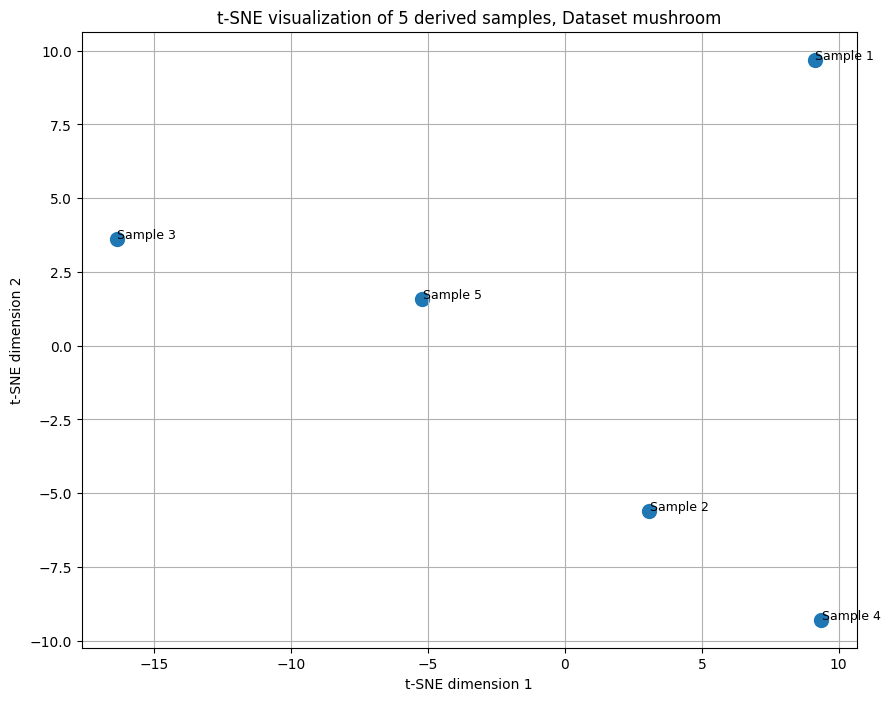

In [23]:
triangulation_samples = get_triangulation_samples("random", 5, X_train_emb)
new_X_train = get_dataset(X_train_emb[:100], triangulation_samples)
new_X_test = get_dataset(X_test_emb[:100], triangulation_samples)
get_preformance(new_X_train, y_train_one_hot[:100], new_X_test, y_test_one_hot[100:])
visualize(triangulation_samples, DATASET_NAME)